In [23]:
#---Core---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#---Visualization---
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

#---Preprocessing---
from sklearn.model_selection import (train_test_split, StratifiedKFold, 
                                    GridSearchCV, RandomizedSearchCV,
                                    cross_val_score)
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

#---Models---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

#---Evaluation---
from sklearn.metrics import (accuracy_score, classification_report,
                            confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

#---Settings---
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries imported successfully!")

All libraries imported successfully!


In [24]:
#---Load Data---
df = pd.read_csv('combined_output.csv')

#---Basic Shape ---
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

#---Source Files Present---
print("\nUnique Source Files:")
print(df['_source_file'].value_counts())

#---Preview---
print("\nData Preview:")
print(df.head(10))

Shape: (136352, 101)

Column Names:
['Player', 'Player ID', '_source_file', 'Abbreviated', 'Full Name', 'Tournament', 'Stage', 'Match Type', 'Match Name', 'Map', 'Round Number', 'Team', 'Loadout Value', 'Remaining Credits', 'Type', 'Outcome', 'Tournament ID', 'Stage ID', 'Match Type ID', 'Agent', 'Total Wins By Map', 'Total Loss By Map', 'Total Maps Played', 'Team ID', 'Initiated', 'Won', 'Action', 'Pick Rate', 'Method', 'Agents', 'Rating', 'Average Combat Score', 'Kills', 'Deaths', 'Assists', 'Kills - Deaths (KD)', 'Kill, Assist, Trade, Survive %', 'Average Damage Per Round', 'Headshot %', 'First Kills', 'First Deaths', 'Kills - Deaths (FKD)', 'Side', 'Teams', 'Rounds Played', 'Kills:Deaths', 'Kills Per Round', 'Assists Per Round', 'First Kills Per Round', 'First Deaths Per Round', 'Clutch Success %', 'Clutches (won/played)', 'Maximum Kills in a Single Map', 'Team A', 'Team B', 'Team A Score', 'Team B Score', 'Match Result', 'Match ID', 'Game ID', 'Elimination', 'Detonated', 'Defused'

In [25]:
# Split combined dataframe into individual source dataframes
source_files = df['_source_file'].unique()

# Create a dictionary to hold the individual dataframes
dfs = {source: df[df['_source_file'] == source].reset_index(drop=True) 
       for source in source_files}

# Preview the most important ones
for name in ['players_stats.csv', 'overview.csv', 'scores.csv',
             'maps_scores.csv', 'maps_stats.csv']:
    print(f"\n{'='*50}")
    print(f"SOURCE: {name}, SHAPE: {dfs[name].shape}")
    # Only show columns that are not all null
    non_null_cols = dfs[name].columns[dfs[name].notna().any()].tolist()
    print(f"Non-null columns: {non_null_cols}")
    print(dfs[name][non_null_cols].head(3))



SOURCE: players_stats.csv, SHAPE: (5231, 101)
Non-null columns: ['Player', '_source_file', 'Tournament', 'Stage', 'Match Type', 'Agents', 'Rating', 'Average Combat Score', 'Kills', 'Deaths', 'Assists', 'Kill, Assist, Trade, Survive %', 'Average Damage Per Round', 'Headshot %', 'First Kills', 'First Deaths', 'Teams', 'Rounds Played', 'Kills:Deaths', 'Kills Per Round', 'Assists Per Round', 'First Kills Per Round', 'First Deaths Per Round', 'Clutch Success %', 'Clutches (won/played)', 'Maximum Kills in a Single Map']
  Player       _source_file                      Tournament     Stage  \
0  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   
1  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   
2  skuba  players_stats.csv  Valorant Masters Santiago 2026  Playoffs   

            Match Type        Agents  Rating  Average Combat Score  Kills  \
0  Upper Quarterfinals         astra    1.93                 289.0   22.0   
1  Upper Quarterfinals         v

In [26]:
# Isolate Player Stats for EDA
ps = dfs['players_stats.csv'].copy()

# Clean Percentage Columns -> Numeric
pct_cols = ['Kill, Assist, Trade, Survive %', 'Headshot %',
            'Clutch Success %']
for col in pct_cols:
    ps[col] = ps[col].astype(str).str.replace('%', '').str.strip()
    ps[col] = pd.to_numeric(ps[col], errors='coerce')

# Aggregate Stats per Team per Match
numeric_features = ['Rating', 'Average Combat Score', 'Kills', 'Deaths',
                    'Assists', 'Kill, Assist, Trade, Survive %',
                    'Average Damage Per Round', 'Headshot %',
                    'First Kills', 'First Deaths', 'Kills Per Round',
                    'Assists Per Round', 'First Kills Per Round',
                    'First Deaths Per Round', 'Clutch Success %']

team_match_stats = (
    ps.groupby(['Tournament', 'Stage', 'Match Type', 'Teams'])[numeric_features]
    .mean()
    .reset_index()
)

print("Team-match aggregated stats shape:", team_match_stats.shape)
print(team_match_stats.head())

Team-match aggregated stats shape: (349, 19)
                   Tournament       Stage       Match Type          Teams  \
0  VCT 2026: Americas Kickoff  All Stages  All Match Types    100 Thieves   
1  VCT 2026: Americas Kickoff  All Stages  All Match Types         Cloud9   
2  VCT 2026: Americas Kickoff  All Stages  All Match Types   Cloud9, ENVY   
3  VCT 2026: Americas Kickoff  All Stages  All Match Types           ENVY   
4  VCT 2026: Americas Kickoff  All Stages  All Match Types  Evil Geniuses   

     Rating  Average Combat Score       Kills  Deaths    Assists  \
0  1.022174            199.304348  132.695652  130.00  56.000000   
1  0.965667            187.900000   72.666667   73.60  34.133333   
2  1.048000            218.600000   56.800000   46.00  10.000000   
3  0.988000            193.750000   89.950000   91.85  33.050000   
4  0.968000            187.900000   86.500000   85.60  34.000000   

   Kill, Assist, Trade, Survive %  Average Damage Per Round  Headshot %  \
0       

In [27]:
# Isolate match results (target variable)
scores = dfs['scores.csv'].copy()
non_null_scores = scores.columns[scores.notna().any()].tolist()
print("\nscores.csv non-null columns:", non_null_scores)
print(scores[non_null_scores].head(10))


scores.csv non-null columns: ['_source_file', 'Tournament', 'Stage', 'Match Type', 'Match Name', 'Team A', 'Team B', 'Team A Score', 'Team B Score', 'Match Result']
  _source_file                      Tournament        Stage     Match Type  \
0   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
1   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
2   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
3   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 1   
4   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (1-0)   
5   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (1-0)   
6   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (0-1)   
7   scores.csv  Valorant Masters Santiago 2026  Swiss Stage  Round 2 (0-1)   
8   scores.csv  Valorant Masters Santiago 2026  Swiss Stage        Round 3   
9   scores.csv  Valorant Masters Santiago 2026  Swiss 

In [28]:
# Clean scores to one row per match
scores_clean = dfs['scores.csv'].copy()
non_null = scores_clean.columns[scores_clean.notna().any()].tolist()
scores_clean = scores_clean[non_null].drop_duplicates(
    subset=['Tournament', 'Stage', 'Match Type', 'Match Name']
).reset_index(drop=True)

print("Unique matches:", len(scores_clean))
print(scores_clean[['Match Name', 'Team A', 'Team B', 
                      'Team A Score', 'Team B Score', 
                      'Match Result']].head(10)) 

Unique matches: 144
                      Match Name         Team A         Team B  Team A Score  \
0  Gentle Mates vs EDward Gaming   Gentle Mates  EDward Gaming           2.0   
1           Xi Lai Gaming vs NRG  Xi Lai Gaming    Mega Minors           0.0   
2        G2 Esports vs Paper Rex     G2 Esports      Paper Rex           0.0   
3              T1 vs Team Liquid             T1    Team Liquid           0.0   
4               Paper Rex vs NRG      Paper Rex    Mega Minors           2.0   
5    Gentle Mates vs Team Liquid   Gentle Mates    Team Liquid           2.0   
6            EDward Gaming vs T1  EDward Gaming             T1           0.0   
7    Xi Lai Gaming vs G2 Esports  Xi Lai Gaming     G2 Esports           0.0   
8             NRG vs Team Liquid    Mega Minors    Team Liquid           2.0   
9               G2 Esports vs T1     G2 Esports             T1           2.0   

   Team B Score      Match Result  
0           0.0  Gentle Mates won  
1           2.0           N

In [29]:
#Create binary target — 1 if Team A won, 0 if Team B won 
scores_clean['target'] = scores_clean.apply(
    lambda row: 1 if str(row['Match Result']).strip()
                     .lower()
                     .startswith(str(row['Team A']).strip().lower())
    else 0, axis=1
)

print("\nTarget distribution:")
print(scores_clean['target'].value_counts())
print(f"\nTeam A win rate: {scores_clean['target'].mean():.2%}")


Target distribution:
target
0    87
1    57
Name: count, dtype: int64

Team A win rate: 39.58%


In [30]:
# Join team A stats
# Rename aggregated stats columns with team_a_ prefix
team_a_stats = team_match_stats.rename(columns={
    'Teams': 'Team A',
    **{col: f'team_a_{col}' for col in numeric_features}
})

# Rename aggregated stats columns with team_b_ prefix
team_b_stats = team_match_stats.rename(columns={
    'Teams': 'Team B',
    **{col: f'team_b_{col}' for col in numeric_features}
})

# Merge Team A stats
match_df = scores_clean.merge(
    team_a_stats[['Tournament', 'Stage', 'Match Type', 'Team A'] + 
                  [f'team_a_{c}' for c in numeric_features]],
    on=['Tournament', 'Stage', 'Match Type', 'Team A'],
    how='left'
)

# Merge Team B stats
match_df = match_df.merge(
    team_b_stats[['Tournament', 'Stage', 'Match Type', 'Team B'] + 
                  [f'team_b_{c}' for c in numeric_features]],
    on=['Tournament', 'Stage', 'Match Type', 'Team B'],
    how='left'
)

print("\nFinal match dataset shape:", match_df.shape)
print("\nMissing values per column:")
print(match_df.isnull().sum()[match_df.isnull().sum() > 0])
print("\nSample rows:")
print(match_df[['Match Name', 'Team A', 'Team B', 'target',
                 'team_a_Rating', 'team_b_Rating']].head(10))


Final match dataset shape: (144, 41)

Missing values per column:
team_a_Rating                             5
team_a_Kill, Assist, Trade, Survive %     5
team_a_Average Damage Per Round           5
team_a_Headshot %                         5
team_a_First Kills Per Round              5
team_a_First Deaths Per Round             5
team_a_Clutch Success %                  32
team_b_Rating                             5
team_b_Kill, Assist, Trade, Survive %     5
team_b_Average Damage Per Round           5
team_b_Headshot %                         5
team_b_First Kills Per Round              5
team_b_First Deaths Per Round             5
team_b_Clutch Success %                  33
dtype: int64

Sample rows:
                      Match Name         Team A         Team B  target  \
0  Gentle Mates vs EDward Gaming   Gentle Mates  EDward Gaming       1   
1           Xi Lai Gaming vs NRG  Xi Lai Gaming    Mega Minors       0   
2        G2 Esports vs Paper Rex     G2 Esports      Paper Rex       

In [31]:
# Overall missing data summary 
total_missing = match_df.isnull().sum()
pct_missing = (match_df.isnull().sum() / len(match_df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': total_missing,
    'Missing %': pct_missing
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Missing Data Summary:")
print(missing_df)
print(f"\nTotal rows: {len(match_df)}")
print(f"Total columns with missing data: {len(missing_df)}")

Missing Data Summary:
                                       Missing Count  Missing %
team_b_Clutch Success %                           33      22.92
team_a_Clutch Success %                           32      22.22
team_a_Rating                                      5       3.47
team_a_Kill, Assist, Trade, Survive %              5       3.47
team_a_Average Damage Per Round                    5       3.47
team_a_Headshot %                                  5       3.47
team_a_First Kills Per Round                       5       3.47
team_a_First Deaths Per Round                      5       3.47
team_b_Rating                                      5       3.47
team_b_Kill, Assist, Trade, Survive %              5       3.47
team_b_Average Damage Per Round                    5       3.47
team_b_Headshot %                                  5       3.47
team_b_First Kills Per Round                       5       3.47
team_b_First Deaths Per Round                      5       3.47

Total rows: 144
T

In [32]:
# Impute missing values 
from sklearn.impute import SimpleImputer

# Separate feature columns
team_a_cols = [f'team_a_{c}' for c in numeric_features]
team_b_cols = [f'team_b_{c}' for c in numeric_features]
all_feature_cols = team_a_cols + team_b_cols

# Impute with median (robust to outliers)
imputer = SimpleImputer(strategy='median')
match_df[all_feature_cols] = imputer.fit_transform(match_df[all_feature_cols])

# Verify no missing values remain
print("Missing values after imputation:")
print(match_df[all_feature_cols].isnull().sum().sum())
print("\nDataset ready for modeling!")
print(f"Final shape: {match_df.shape}")

Missing values after imputation:
0

Dataset ready for modeling!
Final shape: (144, 41)


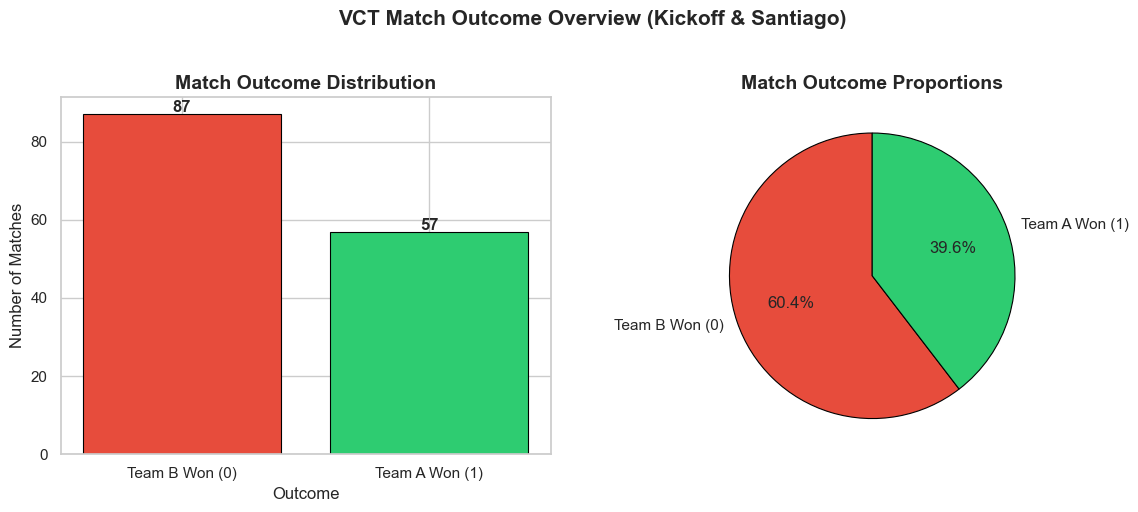

Plot 1 saved!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count of wins 
outcome_counts = match_df['target'].value_counts()
outcome_labels = ['Team B Won (0)', 'Team A Won (1)']
colors = ['#E74C3C', '#2ECC71']

axes[0].bar(outcome_labels, outcome_counts.values, color=colors, 
            edgecolor='black', linewidth=0.8)
axes[0].set_title('Match Outcome Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Matches')
axes[0].set_xlabel('Outcome')
for i, v in enumerate(outcome_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Percentage pie chart 
axes[1].pie(outcome_counts.values, labels=outcome_labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Match Outcome Proportions', fontsize=14, fontweight='bold')

plt.suptitle('VCT Match Outcome Overview (Kickoff & Santiago)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot1_outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved!")

In [34]:
# Reshape data for easier plotting 
# Create a "winning team" and "losing team" stats view

win_ratings = []
lose_ratings = []
win_acs = []
lose_acs = []

for _, row in match_df.iterrows():
    if row['target'] == 1:  # Team A won
        win_ratings.append(row['team_a_Rating'])
        lose_ratings.append(row['team_b_Rating'])
        win_acs.append(row['team_a_Average Combat Score'])
        lose_acs.append(row['team_b_Average Combat Score'])
    else:  # Team B won
        win_ratings.append(row['team_b_Rating'])
        lose_ratings.append(row['team_a_Rating'])
        win_acs.append(row['team_b_Average Combat Score'])
        lose_acs.append(row['team_a_Average Combat Score'])

plot_df = pd.DataFrame({
    'Rating': win_ratings + lose_ratings,
    'ACS': win_acs + lose_acs,
    'Outcome': ['Winner'] * len(win_ratings) + ['Loser'] * len(lose_ratings)
})

print("Plot dataframe shape:", plot_df.shape)
print(plot_df.groupby('Outcome')[['Rating', 'ACS']].describe())

Plot dataframe shape: (288, 3)
        Rating                                                              \
         count      mean       std       min       25%       50%       75%   
Outcome                                                                      
Loser    144.0  0.910835  0.107713  0.584000  0.843929  0.921544  0.970192   
Winner   144.0  1.074256  0.106142  0.745556  1.009006  1.076479  1.132976   

                     ACS                                                 \
              max  count        mean        std         min         25%   
Outcome                                                                   
Loser    1.271111  144.0  185.097825  14.777438  143.692308  176.491667   
Winner   1.483636  144.0  205.463682  15.761926  162.727273  195.741728   

                                             
                50%         75%         max  
Outcome                                      
Loser    186.686508  193.687500  223.600000  
Winner   206.63888

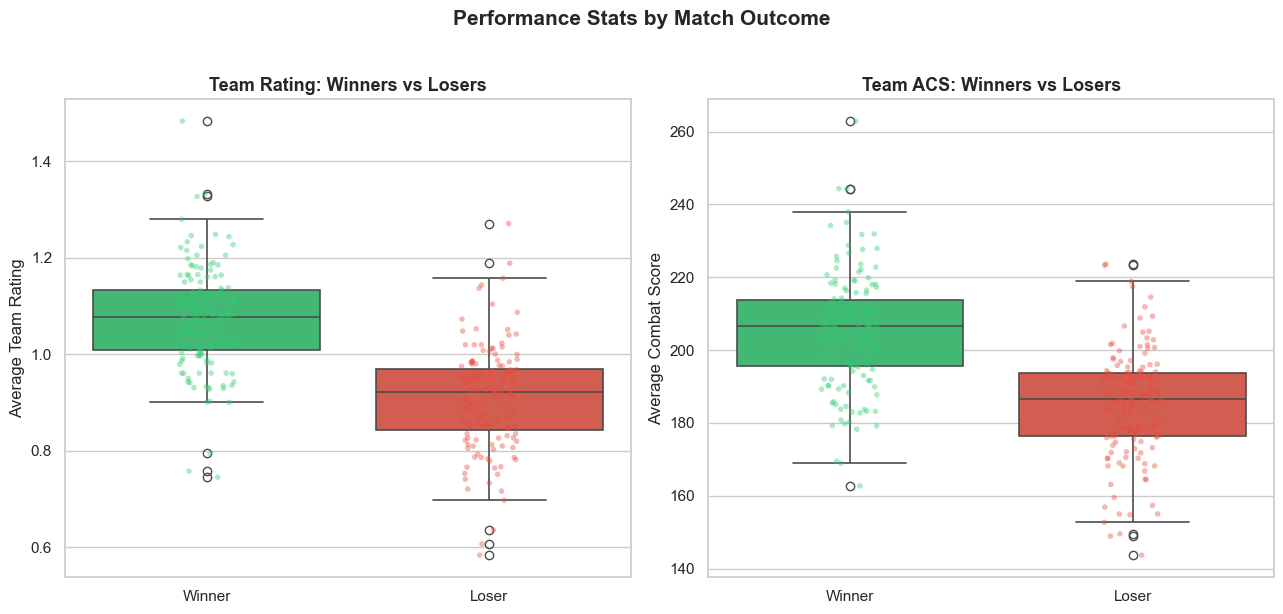

Plot 2 saved!


In [35]:
# Plot 
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
palette = {'Winner': '#2ECC71', 'Loser': '#E74C3C'}

# Boxplot: Rating
sns.boxplot(data=plot_df, x='Outcome', y='Rating',
            palette=palette, ax=axes[0],
            order=['Winner', 'Loser'],
            linewidth=1.2)
sns.stripplot(data=plot_df, x='Outcome', y='Rating',
              palette=palette, ax=axes[0],
              order=['Winner', 'Loser'],
              alpha=0.4, jitter=True, size=4)
axes[0].set_title('Team Rating: Winners vs Losers',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Team Rating')
axes[0].set_xlabel('')

# Boxplot: ACS
sns.boxplot(data=plot_df, x='Outcome', y='ACS',
            palette=palette, ax=axes[1],
            order=['Winner', 'Loser'],
            linewidth=1.2)
sns.stripplot(data=plot_df, x='Outcome', y='ACS',
              palette=palette, ax=axes[1],
              order=['Winner', 'Loser'],
              alpha=0.4, jitter=True, size=4)
axes[1].set_title('Team ACS: Winners vs Losers',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Average Combat Score')
axes[1].set_xlabel('')

plt.suptitle('Performance Stats by Match Outcome',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_plot2_rating_acs_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved!")

In [36]:
# Build correlation matrix using team differentials 
# Instead of correlating team_a and team_b separately,
# we compute the DIFFERENCE (Team A - Team B) for each stat.
# This is more meaningful: a positive diff = Team A was better in that stat.

diff_df = pd.DataFrame()

for col in numeric_features:
    diff_df[f'diff_{col}'] = match_df[f'team_a_{col}'] - match_df[f'team_b_{col}']

diff_df['target'] = match_df['target']

# Rename columns for cleaner plot labels
rename_map = {
    'diff_Rating': 'Rating Diff',
    'diff_Average Combat Score': 'ACS Diff',
    'diff_Kills': 'Kills Diff',
    'diff_Deaths': 'Deaths Diff',
    'diff_Assists': 'Assists Diff',
    'diff_Kill, Assist, Trade, Survive %': 'KAST Diff',
    'diff_Average Damage Per Round': 'ADR Diff',
    'diff_Headshot %': 'HS% Diff',
    'diff_First Kills': 'FK Diff',
    'diff_First Deaths': 'FD Diff',
    'diff_Kills Per Round': 'KPR Diff',
    'diff_Assists Per Round': 'APR Diff',
    'diff_First Kills Per Round': 'FKPR Diff',
    'diff_First Deaths Per Round': 'FDPR Diff',
    'diff_Clutch Success %': 'Clutch% Diff',
    'target': 'Match Result'
}
diff_df = diff_df.rename(columns=rename_map)

print("Differential feature matrix shape:", diff_df.shape)
print(diff_df.head(3))

Differential feature matrix shape: (144, 16)
   Rating Diff   ACS Diff  Kills Diff  Deaths Diff  Assists Diff  KAST Diff  \
0     0.196923  13.868132    5.879121     1.824176      8.054945   4.912088   
1    -0.416573 -28.440559   -2.181818     5.139860     -1.965035 -14.762238   
2    -0.226410 -29.692308   -1.230769     6.384615      2.085470  -2.504274   

    ADR Diff  HS% Diff   FK Diff   FD Diff  KPR Diff  APR Diff  FKPR Diff  \
0   4.043956 -5.681319 -0.186813  1.439560  0.011319  0.195165  -0.031538   
1 -10.300699  2.860140  0.244755  0.216783 -0.129650 -0.112168  -0.003916   
2 -24.974359 -4.948718  1.205128 -0.008547 -0.126667  0.034017   0.033761   

   FDPR Diff  Clutch% Diff  Match Result  
0   0.021099      16.50000             1  
1   0.011958     -22.52381             0  
2  -0.011197     -19.50000             0  


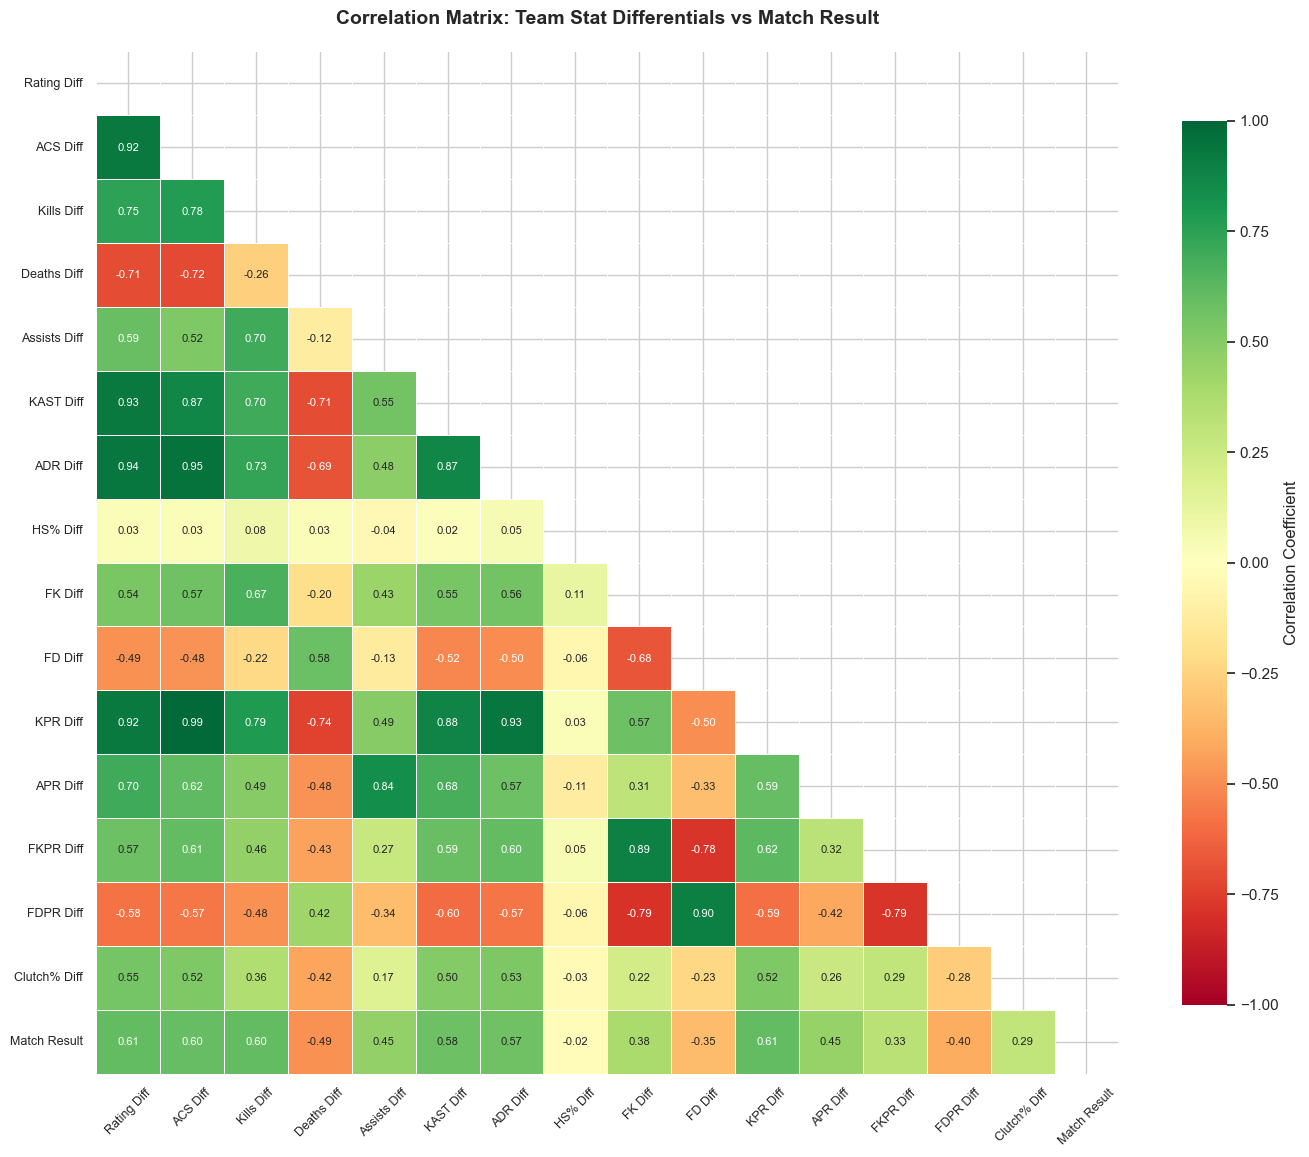

Plot 3 saved!


In [37]:
# Plot correlation heatmap 
corr_matrix = diff_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # mask upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)

ax.set_title('Correlation Matrix: Team Stat Differentials vs Match Result',
             fontsize=14, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig('eda_plot3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved!")